In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Without masking

In [3]:
filename = '/pscratch/sd/l/lflores/astrid_hcd_outputs/Deltas/deltas_0.3_40'
var_tot = []
var_lya, var_hcd, var_lyahcd = [], [], []
var_3lya, var_3hcd, var_4 = [], [], []
Cs = []
for mb_index in np.arange(0, 25, 1):
    with h5py.File(f"{filename}/minibox_{mb_index:02d}.hdf5", 'r') as f:
        # Data
        delta_hcd = f['deltas/delta_hcd'][:]
        delta_lya = f['deltas/delta_lya'][:]
        delta_tot = f['deltas/delta_tot'][:]
        C = (f['C'][()]) 
        
    Cs.append(C)
    var_tot.append(np.mean(delta_tot**2))
    var_lya.append(np.mean(delta_lya**2))
    var_hcd.append(np.mean(delta_hcd**2))
    var_lyahcd.append(np.mean(delta_lya*delta_hcd))
    var_3lya.append(np.mean(delta_lya*delta_hcd*delta_lya))
    var_3hcd.append(np.mean(delta_lya*delta_hcd*delta_hcd))
    var_4.append(np.mean(delta_lya*delta_lya*delta_hcd*delta_hcd) - C**2)

var_tot = np.array(var_tot)
var_lya, var_hcd, var_lyahcd = np.array(var_lya), np.array(var_hcd), np.array(var_lyahcd)
var_3lya, var_3hcd, var_4 = np.array(var_3lya), np.array(var_3hcd), np.array(var_4)
Cs = np.array(Cs)

In [4]:
var_model = (var_lya + var_hcd + 2*var_lyahcd + 2*var_3lya + 2*var_3hcd + var_4)/((1+Cs)**2)

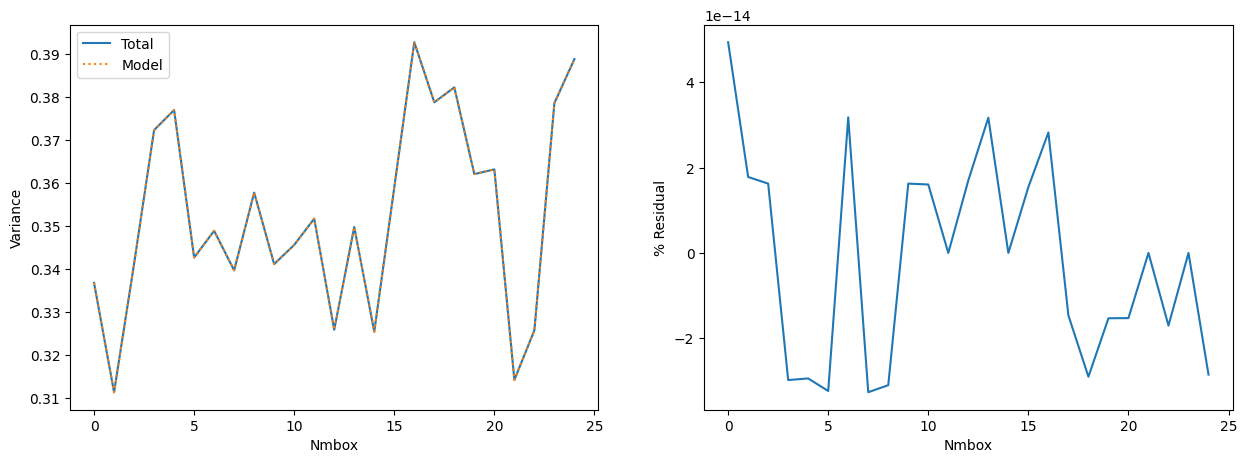

In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(var_tot, label='Total')
plt.plot(var_model, linestyle=':', label='Model')
plt.xlabel('Nmbox')
plt.ylabel('Variance')
plt.legend();

plt.subplot(1, 2, 2)
plt.plot((var_tot-var_model)/var_tot*100, label='Total')
plt.xlabel('Nmbox')
plt.ylabel('% Residual');

# Masking

In [9]:
filename = '/pscratch/sd/l/lflores/astrid_hcd_outputs/Deltas/deltas_0.3_21.3'
var_tot = []
var_lya, var_hcd, var_lyahcd = [], [], []
var_3lya, var_3hcd, var_4 = [], [], []
Cs = []
for mb_index in np.arange(0, 25, 1):
    with h5py.File(f"{filename}/minibox_{mb_index:02d}.hdf5", 'r') as f:
        # Data
        delta_hcd = f['deltas/delta_hcd'][:]
        delta_lya = f['deltas/delta_lya'][:]
        delta_tot = f['deltas/delta_tot'][:]
        C = (f['C'][()]) 
        
    Cs.append(C)
    var_tot.append(np.mean(delta_tot**2))
    var_lya.append(np.mean(delta_lya**2))
    var_hcd.append(np.mean(delta_hcd**2))
    var_lyahcd.append(np.mean(delta_lya*delta_hcd))
    var_3lya.append(np.mean(delta_lya*delta_hcd*delta_lya))
    var_3hcd.append(np.mean(delta_lya*delta_hcd*delta_hcd))
    var_4.append(np.mean(delta_lya*delta_lya*delta_hcd*delta_hcd) - C**2)

var_tot = np.array(var_tot)
var_lya, var_hcd, var_lyahcd = np.array(var_lya), np.array(var_hcd), np.array(var_lyahcd)
var_3lya, var_3hcd, var_4 = np.array(var_3lya), np.array(var_3hcd), np.array(var_4)
Cs = np.array(Cs)

In [13]:
var_model = (var_lya + var_hcd + 2*var_lyahcd + 2*var_3lya + 2*var_3hcd + var_4)/((1+Cs)**2)

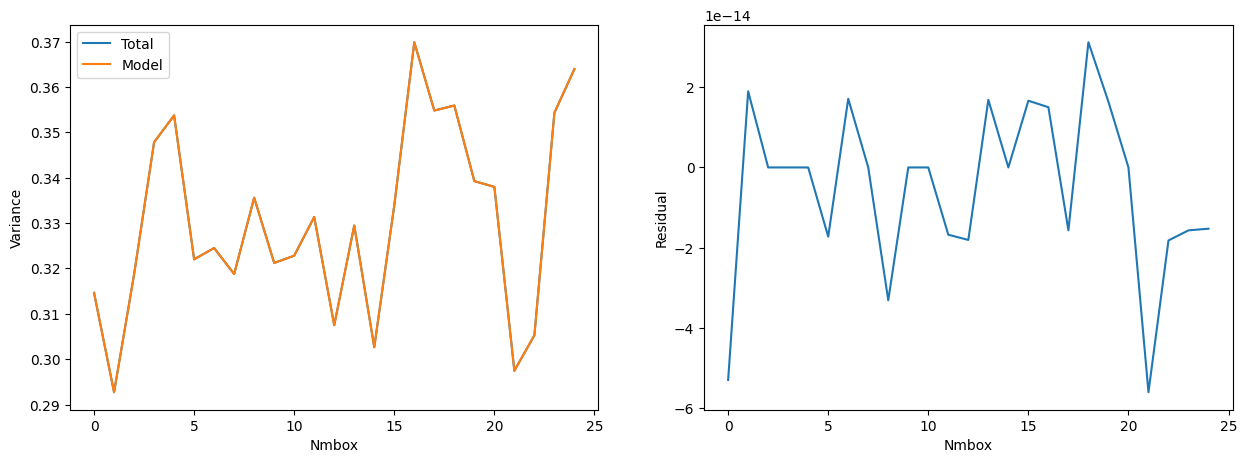

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(var_tot, label='Total')
plt.plot(var_model, label='Model')
plt.xlabel('Nmbox')
plt.ylabel('Variance')
plt.legend();

plt.subplot(1, 2, 2)
plt.plot((var_tot-var_model)/var_tot*100, label='Total')
plt.xlabel('Nmbox')
plt.ylabel('Residual');